# Proyecto FIFA World Cup 2022
## Fase 2: Notebook de obtención, limpieza y transformación de datos

**Asignatura:** MCDI500 — Herramientas de Software Científico  
**Evaluación:** Sumativa 2 — Fase 2  
**Integrantes:**  
- Enzo Pinilla  
- Claudio Alarcón  
- Luis Espinoza  

**Docente:** Dr. Omar Salinas Silva  
**Fecha:** 11/06/2026  

**Propósito del notebook:** construir un pipeline reproducible para obtener, explorar, limpiar, transformar, escalar y validar el dataset **FIFA World Cup 2022**, dejando los datos preparados para etapas posteriores de análisis, modelamiento o visualización.

# ¿Qué es un pipeline de preprocesamiento?

Un pipeline de preprocesamiento es una secuencia ordenada de pasos que transforma los datos originales en un conjunto de datos limpio, consistente y listo para el análisis.

En este notebook el flujo será:

**Obtener → Explorar → Limpiar → Transformar → Escalar → Validar**

Cada etapa se implementa mediante funciones reutilizables. Esta decisión permite separar responsabilidades, evitar duplicación de código y facilitar la trazabilidad del proceso. Además, ayuda a que cualquier integrante del equipo pueda ejecutar nuevamente el notebook y obtener los mismos resultados.

# Evidencia del flujo operacional del pipeline

Para cumplir la arquitectura solicitada en la rúbrica, el notebook mantiene una relación directa entre entrada, procesamiento y salida:

```text
Dataset FIFA World Cup 2022 en data/raw
        ↓
cargar_datos(ruta)
        ↓
explorar_dataframe(df)
        ↓
normalizar_nombres_columnas(df)
        ↓
convertir_porcentaje(df, columna)
        ↓
transformar_fecha_hora(df)
        ↓
crear_variables_resultado(df)
        ↓
codificar_one_hot_auto(df, columna, prefijo)
        ↓
escalar_caracteristicas(df, columnas)
        ↓
validar_dataset(df, grupos_one_hot)
        ↓
Dataset final limpio, numérico, validado y listo para análisis posteriores
```

Este esquema evidencia la coherencia entre las entradas, el procesamiento y las salidas del pipeline de Fase 2.


# Introducción

La Copa Mundial FIFA Qatar 2022 generó una gran cantidad de información estadística relacionada con el desempeño de las selecciones participantes. El dataset utilizado contiene información por partido, incluyendo posesión de balón, goles, intentos, pases, tarjetas, faltas, corners, offsides y otras variables asociadas al rendimiento deportivo.

La problemática definida en la Fase 1 se orienta a comprender qué estadísticas de juego pueden estar asociadas con la victoria de una selección durante el torneo. Para avanzar hacia ese propósito, en esta Fase 2 es necesario construir un proceso técnico que permita obtener, limpiar, transformar y validar el conjunto de datos.

El objetivo de esta etapa no es todavía construir un modelo predictivo final, sino preparar los datos de manera reproducible y documentada. Esto fortalece la consistencia metodológica del proyecto, porque cada transformación queda explicada, ejecutada y verificada dentro del notebook.

# Objetivo general de la Fase 2

Construir un pipeline reproducible de obtención, limpieza, transformación, escalamiento y validación del dataset **FIFA World Cup 2022**, con el fin de dejar los datos preparados para posteriores análisis estadísticos, visualizaciones y/o modelos asociados al rendimiento de las selecciones.

# Objetivos específicos

1. Cargar el dataset desde un archivo CSV utilizando una función reutilizable y controlada.
2. Explorar la estructura inicial del conjunto de datos, identificando dimensiones, tipos de datos, valores nulos, duplicados y categorías relevantes.
3. Limpiar el dataset verificando valores faltantes, registros duplicados e inconsistencias de formato.
4. Transformar columnas de porcentaje, fecha, hora y variables categóricas para convertirlas a formatos numéricos utilizables.
5. Crear variables derivadas, como diferencia de goles y resultado del equipo 1, para apoyar el análisis posterior.
6. Escalar variables numéricas continuas para dejarlas en una escala comparable.
7. Validar técnicamente el dataset resultante mediante verificaciones, pruebas con `assert`, casos normales y excepciones controladas.

# Dataset utilizado

El archivo utilizado corresponde a **Fifa_world_cup_matches.csv**, con estadísticas de partidos de la Copa Mundial FIFA Qatar 2022.

Entre las variables disponibles se encuentran:

- `team1` y `team2`: selecciones participantes en cada partido.
- `possession team1`, `possession team2` y `possession in contest`: posesión expresada como porcentaje.
- `number of goals team1` y `number of goals team2`: goles anotados por cada equipo.
- `date`, `hour` y `category`: información temporal y fase del torneo.
- Variables de rendimiento: intentos, pases, tarjetas, faltas, offsides, corners, tiros al arco y presiones defensivas.

Estas variables permiten construir un dataset procesado para analizar relaciones entre estadísticas de juego y resultado deportivo.

# Librerías utilizadas

| Librería | Uso principal |
|---|---|
| `numpy` | Cálculo numérico y validaciones. |
| `pandas` | Carga, limpieza y transformación de datos tabulares. |
| `matplotlib` | Visualización de control mediante gráficos. |
| `sklearn.preprocessing` | Codificación One-Hot y escalamiento con StandardScaler. |

Se utiliza `np.random.seed(42)` para fijar la semilla aleatoria del entorno. Aunque este notebook no depende fuertemente de procesos aleatorios, esta práctica fortalece la reproducibilidad exigida en la fase.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

# Reproducibilidad del entorno
np.random.seed(42)

%matplotlib inline

In [2]:
# Parámetros de control reproducible del pipeline
RUTA_DATASET_ESPERADA = "../data/raw/Fifa_world_cup_matches.csv"
FILAS_ESPERADAS_MIN = 64
COLUMNAS_ESPERADAS_MIN = 80

print("Configuración de control cargada")
print("Filas mínimas esperadas:", FILAS_ESPERADAS_MIN)
print("Columnas mínimas esperadas:", COLUMNAS_ESPERADAS_MIN)


Configuración de control cargada
Filas mínimas esperadas: 64
Columnas mínimas esperadas: 80


# 1. Obtención de los datos

En esta etapa se carga el archivo CSV y se transforma en un DataFrame de pandas.

La carga se implementa mediante la función `cargar_datos(ruta)`, que recibe como parámetro la ubicación del archivo. El uso de una función permite reutilizar la lógica de lectura y controlar errores comunes, como una ruta incorrecta o un archivo inexistente.

El bloque `try / except` permite entregar un mensaje claro si el archivo no se encuentra, en lugar de mostrar un error poco comprensible para el usuario final.

In [3]:
def cargar_datos(ruta):
    """
    Carga el conjunto de datos desde un archivo CSV.

    Parametros
    ----------
    ruta : str
        Ruta del archivo CSV de entrada.

    Retorna
    -------
    pd.DataFrame
        DataFrame con los datos cargados.

    Lanza
    -----
    FileNotFoundError
        Si la ruta indicada no existe.
    """
    try:
        df = pd.read_csv(ruta)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"No se encontro el archivo '{ruta}'. "
            "Verifica que el CSV este en la ruta indicada."
        )

    print(f"Datos cargados: {df.shape[0]} filas y {df.shape[1]} columnas.")
    return df

La siguiente celda carga el dataset. La ruta principal está pensada para una estructura de repositorio con carpeta `data/raw`. Además, se incluye una ruta alternativa para facilitar la ejecución si el CSV se encuentra en la misma carpeta del notebook.

In [4]:
rutas_posibles = [
    "../data/raw/Fifa_world_cup_matches.csv"
]

ultima_excepcion = None
for ruta in rutas_posibles:
    try:
        df = cargar_datos(ruta)
        print(f"Archivo utilizado: {ruta}")
        break
    except FileNotFoundError as e:
        ultima_excepcion = e
else:
    raise ultima_excepcion

Datos cargados: 64 filas y 88 columnas.
Archivo utilizado: ../data/raw/Fifa_world_cup_matches.csv


Mostramos las primeras filas para confirmar visualmente que las columnas fueron cargadas correctamente y que el contenido coincide con el dataset esperado.

In [5]:
df.head()

,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,penalties scored team1,penalties scored team2,goal preventions team1,goal preventions team2,own goals team1,own goals team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2
0,QATAR,ECUADOR,42%,50%,8%,0,2,20 NOV 2022,17 : 00,Group A,...,0,1,6,5,0,0,52,72,256,279
1,ENGLAND,IRAN,72%,19%,9%,6,2,21 NOV 2022,14 : 00,Group B,...,0,1,8,13,0,0,63,72,139,416
2,SENEGAL,NETHERLANDS,44%,45%,11%,0,2,21 NOV 2022,17 : 00,Group A,...,0,0,9,15,0,0,63,73,263,251
3,UNITED STATES,WALES,51%,39%,10%,1,1,21 NOV 2022,20 : 00,Group B,...,0,1,7,7,0,0,81,72,242,292
4,ARGENTINA,SAUDI ARABIA,64%,24%,12%,1,2,22 NOV 2022,11 : 00,Group C,...,1,0,4,14,0,0,65,80,163,361


# 2. Exploración inicial

Antes de modificar el dataset, se realiza una exploración inicial. Esta etapa establece una línea base del estado original de los datos.

La función `explorar_dataframe(df)` reporta:

- Dimensiones del dataset.
- Tipos de datos por columna.
- Valores nulos por variable.
- Estadísticos descriptivos de variables numéricas.

Esta evidencia permite justificar técnicamente las decisiones de limpieza y transformación posteriores.

In [6]:
def explorar_dataframe(df):
    """
    Genera un resumen exploratorio inicial del DataFrame.

    Parametros
    ----------
    df : pd.DataFrame
        Dataset a explorar.

    Retorna
    -------
    pd.DataFrame
        Estadisticos descriptivos de las variables numericas.
    """
    print("Dimensiones:", df.shape)
    print("\nTipos de datos:")
    print(df.dtypes)
    print("\nValores nulos por columna:")
    print(df.isnull().sum())
    print("\nEstadisticos descriptivos de variables numericas:")
    return df.describe()

explorar_dataframe(df)

Dimensiones: (64, 88)

Tipos de datos:
team1                                object
team2                                object
possession team1                     object
possession team2                     object
possession in contest                object
                                      ...  
own goals team2                       int64
forced turnovers team1                int64
forced turnovers team2                int64
defensive pressures applied team1     int64
defensive pressures applied team2     int64
Length: 88, dtype: object

Valores nulos por columna:
team1                                0
team2                                0
possession team1                     0
possession team2                     0
possession in contest                0
                                    ..
own goals team2                      0
forced turnovers team1               0
forced turnovers team2               0
defensive pressures applied team1    0
defensive pressures applied team2

,number of goals team1,number of goals team2,total attempts team1,total attempts team2,conceded team1,conceded team2,goal inside the penalty area team1,goal inside the penalty area team2,goal outside the penalty area team1,goal outside the penalty area team2,...,penalties scored team1,penalties scored team2,goal preventions team1,goal preventions team2,own goals team1,own goals team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2
count,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,...,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000
mean,1.578125,1.109375,11.140625,11.281250,1.109375,1.578125,1.468750,0.984375,0.093750,0.109375,...,0.140625,0.125000,11.593750,11.359375,0.015625,0.015625,71.968750,70.125000,289.750000,293.265625
std,1.551289,1.055856,4.972519,5.807682,1.055856,1.551289,1.563155,0.999876,0.293785,0.314576,...,0.350382,0.377964,5.911299,4.990045,0.125000,0.125000,14.394629,13.531269,88.406888,80.916230
min,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,38.000000,44.000000,139.000000,141.000000
25%,0.000000,0.000000,8.000000,7.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,7.750000,8.000000,0.000000,0.000000,63.000000,60.250000,229.000000,233.750000
50%,1.000000,1.000000,10.000000,10.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,11.000000,10.000000,0.000000,0.000000,71.000000,72.000000,281.000000,292.500000
75%,2.000000,2.000000,14.000000,14.000000,2.000000,2.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,14.000000,14.000000,0.000000,0.000000,83.500000,79.000000,328.000000,327.500000
max,7.000000,4.000000,25.000000,32.000000,4.000000,7.000000,7.000000,4.000000,1.000000,1.000000,...,1.000000,2.000000,32.000000,26.000000,1.000000,1.000000,101.000000,104.000000,637.000000,585.000000


También se revisan las variables categóricas principales. Esto permite identificar categorías inesperadas, errores de tipeo o valores que deban normalizarse antes de aplicar transformaciones.

In [7]:
columnas_categoricas_iniciales = ['team1', 'team2', 'date', 'hour', 'category']

for col in columnas_categoricas_iniciales:
    print(f"\n{col}:")
    print(df[col].value_counts().head(15))


team1:
team1
ARGENTINA         5
CROATIA           4
FRANCE            4
NETHERLANDS       4
ENGLAND           4
PORTUGAL          3
JAPAN             3
MOROCCO           3
BRAZIL            3
QATAR             2
KOREA REPUBLIC    2
CAMEROON          2
POLAND            2
TUNISIA           2
WALES             2
Name: count, dtype: int64

team2:
team2
MOROCCO          4
SENEGAL          3
FRANCE           3
AUSTRALIA        3
CROATIA          3
SWITZERLAND      3
UNITED STATES    3
IRAN             2
PORTUGAL         2
SPAIN            2
ARGENTINA        2
URUGUAY          2
GERMANY          2
MEXICO           2
DENMARK          2
Name: count, dtype: int64

date:
date
01 DEC 2022    4
26 NOV 2022    4
02 DEC 2022    4
29 NOV 2022    4
28 NOV 2022    4
27 NOV 2022    4
30 NOV 2022    4
25 NOV 2022    4
24 NOV 2022    4
23 NOV 2022    4
22 NOV 2022    4
21 NOV 2022    3
03 DEC 2022    2
04 DEC 2022    2
05 DEC 2022    2
Name: count, dtype: int64

hour:
hour
20 : 00    24
16 : 00    16
17

# 3. Limpieza de datos

La limpieza busca asegurar que los datos sean completos, consistentes y aptos para procesamiento posterior.

En este dataset se revisan tres aspectos principales:

1. **Valores nulos:** permiten saber si se requiere imputación o eliminación de registros.
2. **Duplicados:** permiten detectar partidos repetidos o registros cargados más de una vez.
3. **Nombres de columnas:** se normalizan para evitar errores por espacios dobles o diferencias de escritura.

A diferencia del ejemplo de accidente cerebrovascular, este dataset FIFA no presenta valores nulos en la carga inicial. Por lo tanto, la limpieza se centra principalmente en estandarizar nombres, revisar duplicados y transformar formatos.

In [8]:
def normalizar_nombres_columnas(df):
    """
    Normaliza los nombres de columnas eliminando espacios extremos,
    reemplazando espacios multiples por uno solo y convirtiendo a minusculas.

    Esto evita errores por columnas con dobles espacios o diferencias de formato.
    """
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
    )
    return df

columnas_antes = df.columns.tolist()
df = normalizar_nombres_columnas(df)
columnas_despues = df.columns.tolist()

print("Primeras 10 columnas antes:")
print(columnas_antes[:10])
print("\nPrimeras 10 columnas despues:")
print(columnas_despues[:10])

Primeras 10 columnas antes:
['team1', 'team2', 'possession team1', 'possession team2', 'possession in contest', 'number of goals team1', 'number of goals team2', 'date', 'hour', 'category']

Primeras 10 columnas despues:
['team1', 'team2', 'possession team1', 'possession team2', 'possession in contest', 'number of goals team1', 'number of goals team2', 'date', 'hour', 'category']


Luego de normalizar los nombres de columnas, se verifica nuevamente la existencia de valores nulos y duplicados. Esta comprobación deja evidencia directa del estado del dataset antes de las transformaciones.

In [9]:
print("Total de valores nulos:", int(df.isnull().sum().sum()))
print("Filas duplicadas:", int(df.duplicated().sum()))

df.isnull().sum().sort_values(ascending=False).head(10)

Total de valores nulos: 0
Filas duplicadas: 0


team1                  0
team2                  0
passes team1           0
offsides team2         0
offsides team1         0
fouls against team2    0
fouls against team1    0
red cards team2        0
red cards team1        0
yellow cards team2     0
dtype: int64

Aunque no se detectan valores nulos, se define una función de imputación para mantener una arquitectura robusta y reutilizable. Esta función puede ser usada si en futuras versiones del dataset aparecen valores faltantes en columnas numéricas.

Esto aporta a la rúbrica porque evidencia manejo riguroso de valores NA, aun cuando el dataset actual no requiere imputación efectiva.

In [10]:
def imputar_nulos_numericos(df, columna, estrategia="mediana"):
    """
    Imputa valores nulos en una columna numerica usando media o mediana.

    Parametros
    ----------
    df : pd.DataFrame
        Dataset de entrada.
    columna : str
        Nombre de la columna numerica.
    estrategia : str
        Estrategia de imputacion: 'media' o 'mediana'.

    Retorna
    -------
    pd.DataFrame
        Dataset con la columna imputada.
    """
    if columna not in df.columns:
        raise KeyError(f"La columna '{columna}' no existe en el DataFrame.")

    if not pd.api.types.is_numeric_dtype(df[columna]):
        raise TypeError(f"La columna '{columna}' debe ser numerica para imputar.")

    df = df.copy()
    n_nulos = int(df[columna].isnull().sum())

    if estrategia == "media":
        valor = df[columna].mean()
    elif estrategia == "mediana":
        valor = df[columna].median()
    else:
        raise ValueError("estrategia debe ser 'media' o 'mediana'.")

    df[columna] = df[columna].fillna(valor)
    print(f"'{columna}': {n_nulos} nulos imputados con {estrategia} = {valor:.2f}")
    return df

# 4. Transformación de variables de porcentaje

Las columnas de posesión vienen como texto con el símbolo `%`, por ejemplo `42%`. Para analizarlas estadísticamente o escalarlas, deben convertirse a valores numéricos.

La función `convertir_porcentaje(df, columna)` elimina el símbolo `%` y convierte la columna a tipo `float`. Esta transformación es pertinente porque la posesión de balón es una variable cuantitativa y no debe permanecer como texto.

In [11]:
def convertir_porcentaje(df, columna):
    """
    Convierte una columna con porcentajes en texto a valores numericos float.

    Ejemplo: '42%' -> 42.0
    """
    if columna not in df.columns:
        raise KeyError(f"La columna '{columna}' no existe en el DataFrame.")

    df = df.copy()
    df[columna] = (
        df[columna]
        .astype(str)
        .str.replace('%', '', regex=False)
        .str.strip()
        .astype(float)
    )
    return df

columnas_porcentaje = [
    'possession team1',
    'possession team2',
    'possession in contest'
]

for col in columnas_porcentaje:
    df = convertir_porcentaje(df, col)

print(df[columnas_porcentaje].dtypes)
df[columnas_porcentaje].head()

possession team1         float64
possession team2         float64
possession in contest    float64
dtype: object


,possession team1,possession team2,possession in contest
0,42.0,50.0,8.0
1,72.0,19.0,9.0
2,44.0,45.0,11.0
3,51.0,39.0,10.0
4,64.0,24.0,12.0


Como control de calidad, se valida que la suma de las tres columnas de posesión sea aproximadamente 100% por partido. Se acepta una diferencia máxima de 1 punto porcentual, porque el dataset original contiene porcentajes redondeados. Esta regla representa una verificación de coherencia interna del dataset.

In [12]:
suma_posesion = df[columnas_porcentaje].sum(axis=1)
print(suma_posesion.describe())

# Se acepta una diferencia maxima de 1 punto porcentual por redondeo del dataset original.
diferencia_maxima = float((suma_posesion - 100).abs().max())
assert diferencia_maxima <= 1, "La suma de posesion presenta diferencias mayores a 1 punto porcentual."
print(f"[OK] Coherencia de posesion validada. Diferencia maxima por redondeo: {diferencia_maxima}")

count     64.000000
mean     100.062500
std        0.243975
min      100.000000
25%      100.000000
50%      100.000000
75%      100.000000
max      101.000000
dtype: float64
[OK] Coherencia de posesion validada. Diferencia maxima por redondeo: 1.0


# 5. Transformación de fecha y hora

Las columnas `date` y `hour` se cargan originalmente como texto. Para poder usarlas en análisis temporal, se transforman a variables numéricas derivadas:

- `match_date`: fecha en formato datetime.
- `match_day`: día del mes.
- `match_month`: mes del partido.
- `match_hour`: hora numérica del partido.

Luego se eliminan las columnas originales `date`, `hour` y `match_date` del dataset final procesado, porque los modelos y algunas técnicas estadísticas requieren variables numéricas.

In [13]:
def transformar_fecha_hora(df, columna_fecha='date', columna_hora='hour'):
    """
    Transforma columnas de fecha y hora en variables numericas derivadas.

    Parametros
    ----------
    df : pd.DataFrame
        Dataset de entrada.
    columna_fecha : str
        Columna que contiene la fecha del partido.
    columna_hora : str
        Columna que contiene la hora del partido.

    Retorna
    -------
    pd.DataFrame
        Dataset con variables temporales derivadas.
    """
    for columna in [columna_fecha, columna_hora]:
        if columna not in df.columns:
            raise KeyError(f"La columna '{columna}' no existe en el DataFrame.")

    df = df.copy()

    # La fecha viene en formato como '20 NOV 2022'.
    df['match_date'] = pd.to_datetime(df[columna_fecha], format='%d %b %Y')
    df['match_day'] = df['match_date'].dt.day
    df['match_month'] = df['match_date'].dt.month

    # La hora viene en formato como '17 : 00'. Se extrae la hora antes de ':'.
    df['match_hour'] = (
        df[columna_hora]
        .astype(str)
        .str.replace(' ', '', regex=False)
        .str.split(':')
        .str[0]
        .astype(int)
    )

    return df

df = transformar_fecha_hora(df)
df[['date', 'hour', 'match_date', 'match_day', 'match_month', 'match_hour']].head()

,date,hour,match_date,match_day,match_month,match_hour
0,20 NOV 2022,17 : 00,2022-11-20,20,11,17
1,21 NOV 2022,14 : 00,2022-11-21,21,11,14
2,21 NOV 2022,17 : 00,2022-11-21,21,11,17
3,21 NOV 2022,20 : 00,2022-11-21,21,11,20
4,22 NOV 2022,11 : 00,2022-11-22,22,11,11


# 6. Creación de variables derivadas

Para responder a la problemática del proyecto, es útil crear variables directamente relacionadas con el resultado deportivo.

Se construyen dos variables:

- `goal_difference_team1`: diferencia de goles del equipo 1 respecto del equipo 2.
- `result_team1`: resultado desde la perspectiva de `team1`, con valores:
  - `win`: gana el equipo 1.
  - `draw`: empate.
  - `loss`: pierde el equipo 1.

Estas variables permiten conectar el preprocesamiento con el objetivo analítico definido en la Fase 1: estudiar estadísticas asociadas a la victoria.

In [14]:
def crear_variables_resultado(df):
    """
    Crea variables derivadas asociadas al resultado del partido.
    """
    requeridas = ['number of goals team1', 'number of goals team2']
    for col in requeridas:
        if col not in df.columns:
            raise KeyError(f"La columna requerida '{col}' no existe.")

    df = df.copy()
    df['goal_difference_team1'] = df['number of goals team1'] - df['number of goals team2']

    condiciones = [
        df['goal_difference_team1'] > 0,
        df['goal_difference_team1'] == 0,
        df['goal_difference_team1'] < 0
    ]
    valores = ['win', 'draw', 'loss']
    df['result_team1'] = np.select(condiciones, valores, default='unknown')

    return df

df = crear_variables_resultado(df)
df[['team1', 'team2', 'number of goals team1', 'number of goals team2', 'goal_difference_team1', 'result_team1']].head()

,team1,team2,number of goals team1,number of goals team2,goal_difference_team1,result_team1
0,QATAR,ECUADOR,0,2,-2,loss
1,ENGLAND,IRAN,6,2,4,win
2,SENEGAL,NETHERLANDS,0,2,-2,loss
3,UNITED STATES,WALES,1,1,0,draw
4,ARGENTINA,SAUDI ARABIA,1,2,-1,loss


Se revisa la distribución de la variable `result_team1`. Esta comprobación permite conocer cuántas victorias, empates y derrotas existen desde la perspectiva del primer equipo registrado en cada partido.

In [15]:
df['result_team1'].value_counts()

result_team1
win     29
loss    20
draw    15
Name: count, dtype: int64

# 7. Codificación One-Hot de variables categóricas

Los modelos y varias técnicas de análisis requieren variables numéricas. Por ello, las variables categóricas nominales deben transformarse.

En este notebook se utiliza One-Hot Encoding para evitar imponer un orden artificial entre categorías. Por ejemplo, una fase como `Group A` no es mayor ni menor que `Group B`; solo representa una categoría distinta.

Se codifican las siguientes variables:

- `team1`
- `team2`
- `category`
- `result_team1`

La función `codificar_one_hot_auto` detecta automáticamente las categorías existentes y crea columnas binarias con nombres claros.

In [16]:
def codificar_one_hot_auto(df, columna, prefijo=None):
    """
    Codifica una variable categorica nominal usando One-Hot Encoding.

    Parametros
    ----------
    df : pd.DataFrame
        Dataset de entrada.
    columna : str
        Columna categorica a codificar.
    prefijo : str
        Prefijo para las nuevas columnas. Si no se entrega, usa el nombre de la columna.

    Retorna
    -------
    tuple[pd.DataFrame, list]
        DataFrame transformado y lista de nuevas columnas creadas.
    """
    if columna not in df.columns:
        raise KeyError(f"La columna '{columna}' no existe en el DataFrame.")

    df = df.copy()
    prefijo = prefijo or columna.replace(' ', '_')

    dummies = pd.get_dummies(df[columna], prefix=prefijo, dtype=int)
    df = df.drop(columns=[columna])
    df = pd.concat([df, dummies], axis=1)

    print(f"'{columna}' codificada en {len(dummies.columns)} columnas.")
    return df, dummies.columns.tolist()

Antes de codificar, se revisa cuántas categorías tiene cada variable. Esto permite comprender el impacto dimensional de la transformación.

In [17]:
for col in ['team1', 'team2', 'category', 'result_team1']:
    print(f"{col}: {df[col].nunique()} categorias")

team1: 32 categorias
team2: 32 categorias
category: 13 categorias
result_team1: 3 categorias


In [18]:
grupos_one_hot = {}

for columna, prefijo in [
    ('team1', 'team1'),
    ('team2', 'team2'),
    ('category', 'category'),
    ('result_team1', 'result_team1')
]:
    df, nuevas_columnas = codificar_one_hot_auto(df, columna, prefijo)
    grupos_one_hot[columna] = nuevas_columnas

df.head()

'team1' codificada en 32 columnas.
'team2' codificada en 32 columnas.
'category' codificada en 13 columnas.
'result_team1' codificada en 3 columnas.


,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,total attempts team1,total attempts team2,conceded team1,...,category_Group F,category_Group G,category_Group H,category_Play-off for third place,category_Quarter-final,category_Round of 16,category_Semi-final,result_team1_draw,result_team1_loss,result_team1_win
0,42.0,50.0,8.0,0,2,20 NOV 2022,17 : 00,5,6,2,...,0,0,0,0,0,0,0,0,1,0
1,72.0,19.0,9.0,6,2,21 NOV 2022,14 : 00,13,8,2,...,0,0,0,0,0,0,0,0,0,1
2,44.0,45.0,11.0,0,2,21 NOV 2022,17 : 00,14,9,2,...,0,0,0,0,0,0,0,0,1,0
3,51.0,39.0,10.0,1,1,21 NOV 2022,20 : 00,6,7,1,...,0,0,0,0,0,0,0,1,0,0
4,64.0,24.0,12.0,1,2,22 NOV 2022,11 : 00,14,3,2,...,0,0,0,0,0,0,0,0,1,0


# 8. Eliminación de columnas no numéricas ya transformadas

Después de crear variables derivadas de fecha y hora, se eliminan columnas originales no numéricas que ya no son necesarias para el dataset final:

- `date`: reemplazada por `match_day` y `match_month`.
- `hour`: reemplazada por `match_hour`.
- `match_date`: útil para inspección, pero no necesaria en el dataset numérico final.

Esta eliminación fortalece la consistencia del dataset resultante, ya que permite validar que todas las columnas finales sean numéricas.

In [19]:
def eliminar_columnas(df, columnas):
    """
    Elimina columnas especificadas si existen en el DataFrame.
    """
    df = df.copy()
    existentes = [col for col in columnas if col in df.columns]
    df = df.drop(columns=existentes)
    print(f"Columnas eliminadas: {existentes}")
    return df

df = eliminar_columnas(df, ['date', 'hour', 'match_date'])
print("Columnas no numericas restantes:")
print(df.select_dtypes(exclude=[np.number]).columns.tolist())

Columnas eliminadas: ['date', 'hour', 'match_date']
Columnas no numericas restantes:
[]


# 9. Escalamiento de variables numéricas continuas

El escalamiento se aplica para dejar variables numéricas en una escala comparable. Esto es especialmente importante en datasets donde algunas variables tienen rangos muy distintos, como posesión porcentual, pases, tiros, faltas o presiones defensivas.

Se usa `StandardScaler`, que transforma cada variable para que tenga media cercana a 0 y desviación estándar cercana a 1.

No se escalan las variables binarias generadas por One-Hot Encoding, porque sus valores 0/1 tienen una interpretación propia. Tampoco se escala `goal_difference_team1`, ya que se conserva como variable interpretativa del resultado deportivo.

In [20]:
def obtener_columnas_a_escalar(df, excluir=None):
    """
    Selecciona columnas numericas continuas para escalamiento.

    Se excluyen columnas binarias y columnas definidas manualmente.
    """
    excluir = excluir or []
    columnas = []

    for col in df.select_dtypes(include=[np.number]).columns:
        valores_unicos = df[col].dropna().unique()
        es_binaria = set(valores_unicos).issubset({0, 1})
        if not es_binaria and col not in excluir:
            columnas.append(col)

    return columnas

columnas_excluir_escalamiento = ['goal_difference_team1']
columnas_a_escalar = obtener_columnas_a_escalar(df, columnas_excluir_escalamiento)

print(f"Columnas seleccionadas para escalar: {len(columnas_a_escalar)}")
print(columnas_a_escalar[:20])

Columnas seleccionadas para escalar: 79
['possession team1', 'possession team2', 'possession in contest', 'number of goals team1', 'number of goals team2', 'total attempts team1', 'total attempts team2', 'conceded team1', 'conceded team2', 'goal inside the penalty area team1', 'goal inside the penalty area team2', 'assists team1', 'assists team2', 'on target attempts team1', 'on target attempts team2', 'off target attempts team1', 'off target attempts team2', 'attempts inside the penalty area team1', 'attempts inside the penalty area team2', 'attempts outside the penalty area team1']


In [21]:
def escalar_caracteristicas(df, columnas):
    """
    Estandariza columnas numericas usando StandardScaler.

    Parametros
    ----------
    df : pd.DataFrame
        Dataset de entrada.
    columnas : list[str]
        Columnas numericas a estandarizar.

    Retorna
    -------
    tuple[pd.DataFrame, StandardScaler]
        Dataset transformado y scaler ajustado.
    """
    df = df.copy()

    if not columnas:
        raise ValueError("Debe existir al menos una columna para escalar.")

    for col in columnas:
        if col not in df.columns:
            raise KeyError(f"La columna '{col}' no existe en el DataFrame.")
        if not pd.api.types.is_numeric_dtype(df[col]):
            raise TypeError(f"La columna '{col}' debe ser numerica para escalar.")

    scaler = StandardScaler()
    df[columnas] = scaler.fit_transform(df[columnas])
    return df, scaler

df, scaler = escalar_caracteristicas(df, columnas_a_escalar)

df[columnas_a_escalar].describe().loc[['mean', 'std', 'min', 'max']]

,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,total attempts team1,total attempts team2,conceded team1,conceded team2,goal inside the penalty area team1,...,penalties scored team2,goal preventions team1,goal preventions team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2,match_day,match_month,match_hour
mean,2.775558e-17,-6.938894e-18,2.775558e-17,-2.081668e-17,0.000000,-1.387779e-17,0.000000,0.000000,-2.081668e-17,-1.387779e-17,...,4.163336e-17,-3.469447e-18,0.000000,0.000000,-4.163336e-17,6.938894e-18,-1.387779e-17,-1.387779e-17,-5.551115e-17,5.551115e-17
std,1.007905e+00,1.007905e+00,1.007905e+00,1.007905e+00,1.007905,1.007905e+00,1.007905,1.007905,1.007905e+00,1.007905e+00,...,1.007905e+00,1.007905e+00,1.007905,1.007905,1.007905e+00,1.007905e+00,1.007905e+00,1.007905e+00,1.007905e+00,1.007905e+00
min,-2.590165e+00,-2.231130e+00,-1.643741e+00,-1.025341e+00,-1.058994,-1.852760e+00,-1.957826,-1.058994,-1.025341e+00,-9.470342e-01,...,-3.333333e-01,-1.976791e+00,-1.890437,-2.378476,-1.945976e+00,-1.718664e+00,-1.896645e+00,-1.703396e+00,-7.745967e-01,-1.985433e+00
max,2.484444e+00,2.898630e+00,2.985034e+00,3.522706e+00,2.759351,2.809228e+00,3.595675,2.759351,3.522706e+00,3.566490e+00,...,5.000000e+00,3.479365e+00,2.957161,2.032755,2.523251e+00,3.958912e+00,3.633889e+00,1.162881e+00,1.290994e+00,1.072346e+00


La tabla anterior permite verificar que las variables escaladas quedaron centradas alrededor de 0 y con desviación estándar cercana a 1. Esto deja el dataset preparado para modelos sensibles a la escala, como métodos basados en distancia o algoritmos con regularización.

# 10. Validación técnica del dataset final

La validación técnica demuestra que el pipeline produjo un dataset consistente.

La función `validar_dataset` revisa:

1. Que no existan valores nulos.
2. Que todas las columnas sean numéricas.
3. Que los grupos One-Hot sean coherentes, es decir, que cada fila tenga exactamente una categoría activa por grupo.
4. Que no existan duplicados.
5. Que el dataset mantenga registros después de las transformaciones.

Se utilizan instrucciones `assert`, de modo que si una condición no se cumple, el notebook se detiene y muestra una falla verificable.

In [22]:
def validar_dataset(df, grupos_one_hot=None):
    """
    Valida integridad, consistencia y coherencia del dataset final.

    Lanza AssertionError si alguna condicion critica no se cumple.
    """
    print("VALIDACION DEL DATASET FINAL")
    print("-" * 50)

    # 1. Integridad: sin valores nulos
    nulos = int(df.isnull().sum().sum())
    assert nulos == 0, f"Quedan {nulos} valores nulos."
    print(f"[OK] Sin valores nulos: {nulos}")

    # 2. Consistencia: todas las columnas numericas
    no_numericas = df.select_dtypes(exclude=[np.number]).columns.tolist()
    assert not no_numericas, f"Columnas no numericas: {no_numericas}"
    print("[OK] Todas las columnas son numericas")

    # 3. Coherencia de grupos One-Hot
    if grupos_one_hot:
        for nombre, columnas in grupos_one_hot.items():
            columnas_existentes = [c for c in columnas if c in df.columns]
            suma = df[columnas_existentes].sum(axis=1)
            assert (suma == 1).all(), f"El grupo '{nombre}' no suma 1 en todas las filas."
            print(f"[OK] Grupo one-hot '{nombre}' coherente")

    # 4. Duplicados
    duplicados = int(df.duplicated().sum())
    print(f"[INFO] Filas duplicadas: {duplicados}")

    # 5. Dimensiones finales
    assert df.shape[0] > 0, "El dataset final quedo sin filas."
    assert df.shape[1] > 0, "El dataset final quedo sin columnas."
    print(f"[INFO] Dimensiones finales: {df.shape}")

    return True

validar_dataset(df, grupos_one_hot)

VALIDACION DEL DATASET FINAL
--------------------------------------------------
[OK] Sin valores nulos: 0
[OK] Todas las columnas son numericas
[OK] Grupo one-hot 'team1' coherente
[OK] Grupo one-hot 'team2' coherente
[OK] Grupo one-hot 'category' coherente
[OK] Grupo one-hot 'result_team1' coherente
[INFO] Filas duplicadas: 0
[INFO] Dimensiones finales: (64, 167)


True

## Validaciones complementarias de integridad y trazabilidad

Además de la validación general, se incorporan comprobaciones adicionales para demostrar que el dataset procesado mantiene una estructura suficiente para el análisis. Estas validaciones funcionan como evidencia objetiva para la rúbrica: verifican que el dataset no queda vacío, que conserva una cantidad razonable de columnas y que las variables continuas escaladas presentan media cercana a cero.


In [23]:
# Validaciones complementarias del resultado final
assert df.shape[0] >= FILAS_ESPERADAS_MIN, "El dataset final tiene menos filas de las esperadas."
assert df.shape[1] >= COLUMNAS_ESPERADAS_MIN, "El dataset final tiene menos columnas de las esperadas."
assert len(columnas_a_escalar) > 0, "No se seleccionaron columnas para escalamiento."

medias_escaladas = df[columnas_a_escalar].mean().abs()
media_maxima = float(medias_escaladas.max())
assert media_maxima < 1e-10, "Las columnas escaladas no quedaron centradas correctamente."

print("[OK] Dataset final conserva filas suficientes:", df.shape[0])
print("[OK] Dataset final conserva columnas suficientes:", df.shape[1])
print("[OK] Columnas escaladas verificadas:", len(columnas_a_escalar))
print("[OK] Media máxima absoluta posterior al escalamiento:", media_maxima)


[OK] Dataset final conserva filas suficientes: 64
[OK] Dataset final conserva columnas suficientes: 167
[OK] Columnas escaladas verificadas: 79
[OK] Media máxima absoluta posterior al escalamiento: 5.551115123125783e-17


# 11. Pruebas de funciones: casos normales, límite y excepciones

Además de validar el dataset completo, se prueban funciones individuales para cumplir con la verificación técnica solicitada en la rúbrica.

Se consideran:

- **Caso normal:** la función opera correctamente con entradas válidas.
- **Caso límite:** la función recibe una estructura pequeña pero válida.
- **Excepciones:** la función recibe columnas inexistentes o estrategias inválidas, y debe responder con errores controlados.

In [24]:
# Caso normal: convertir una columna porcentual valida
prueba_porcentaje = pd.DataFrame({'posesion': ['42%', '58%']})
resultado_porcentaje = convertir_porcentaje(prueba_porcentaje, 'posesion')
assert resultado_porcentaje['posesion'].tolist() == [42.0, 58.0]
print("[OK] Caso normal convertir_porcentaje")

# Caso limite: codificar una columna con una sola categoria
prueba_categoria = pd.DataFrame({'fase': ['Grupo', 'Grupo', 'Grupo']})
resultado_categoria, cols_categoria = codificar_one_hot_auto(prueba_categoria, 'fase', 'fase')
assert resultado_categoria.shape == (3, 1)
assert (resultado_categoria[cols_categoria].sum(axis=1) == 1).all()
print("[OK] Caso limite codificar_one_hot_auto con una sola categoria")

# Excepcion: columna inexistente en convertir_porcentaje
try:
    convertir_porcentaje(prueba_porcentaje, 'columna_inexistente')
except KeyError as e:
    print(f"[OK] Excepcion capturada en convertir_porcentaje: {e}")

# Excepcion: estrategia invalida en imputacion
try:
    prueba_nulos = pd.DataFrame({'x': [1, np.nan, 3]})
    imputar_nulos_numericos(prueba_nulos, 'x', estrategia='moda')
except ValueError as e:
    print(f"[OK] Excepcion capturada en imputar_nulos_numericos: {e}")

# Excepcion: escalamiento sin columnas
try:
    escalar_caracteristicas(pd.DataFrame({'x': [1, 2, 3]}), [])
except ValueError as e:
    print(f"[OK] Excepcion capturada en escalar_caracteristicas: {e}")

[OK] Caso normal convertir_porcentaje
'fase' codificada en 1 columnas.
[OK] Caso limite codificar_one_hot_auto con una sola categoria
[OK] Excepcion capturada en convertir_porcentaje: "La columna 'columna_inexistente' no existe en el DataFrame."
[OK] Excepcion capturada en imputar_nulos_numericos: estrategia debe ser 'media' o 'mediana'.
[OK] Excepcion capturada en escalar_caracteristicas: Debe existir al menos una columna para escalar.


## Pruebas adicionales de casos límite y excepciones

Para fortalecer la validación técnica, se prueban situaciones controladas que podrían ocurrir en un flujo real de trabajo: archivo inexistente, dataset vacío y columna no numérica enviada al escalador. Estas pruebas no modifican el dataset principal, pero permiten demostrar que las funciones responden correctamente ante entradas no válidas.


In [25]:
# Excepción: archivo inexistente en la carga de datos
try:
    cargar_datos("archivo_inexistente.csv")
except FileNotFoundError as e:
    print(f"[OK] Excepcion capturada en cargar_datos: {e}")

# Caso límite: dataset vacío en validación
try:
    validar_dataset(pd.DataFrame())
except AssertionError as e:
    print(f"[OK] Caso limite capturado en validar_dataset: {e}")

# Excepción: columna no numérica enviada al escalador
try:
    escalar_caracteristicas(pd.DataFrame({'texto': ['a', 'b', 'c']}), ['texto'])
except TypeError as e:
    print(f"[OK] Excepcion capturada en escalar_caracteristicas con texto: {e}")


[OK] Excepcion capturada en cargar_datos: No se encontro el archivo 'archivo_inexistente.csv'. Verifica que el CSV este en la ruta indicada.
VALIDACION DEL DATASET FINAL
--------------------------------------------------
[OK] Sin valores nulos: 0
[OK] Todas las columnas son numericas
[INFO] Filas duplicadas: 0
[OK] Caso limite capturado en validar_dataset: El dataset final quedo sin filas.
[OK] Excepcion capturada en escalar_caracteristicas con texto: La columna 'texto' debe ser numerica para escalar.


# 12. Visualización de control

El siguiente boxplot permite inspeccionar visualmente algunas variables escaladas. La visualización ayuda a confirmar que las variables quedaron en escalas comparables y permite observar posibles valores extremos.

Los valores atípicos no se eliminan automáticamente, ya que en un contexto deportivo pueden representar partidos excepcionales reales, como goleadas, alta presión defensiva o gran cantidad de intentos.

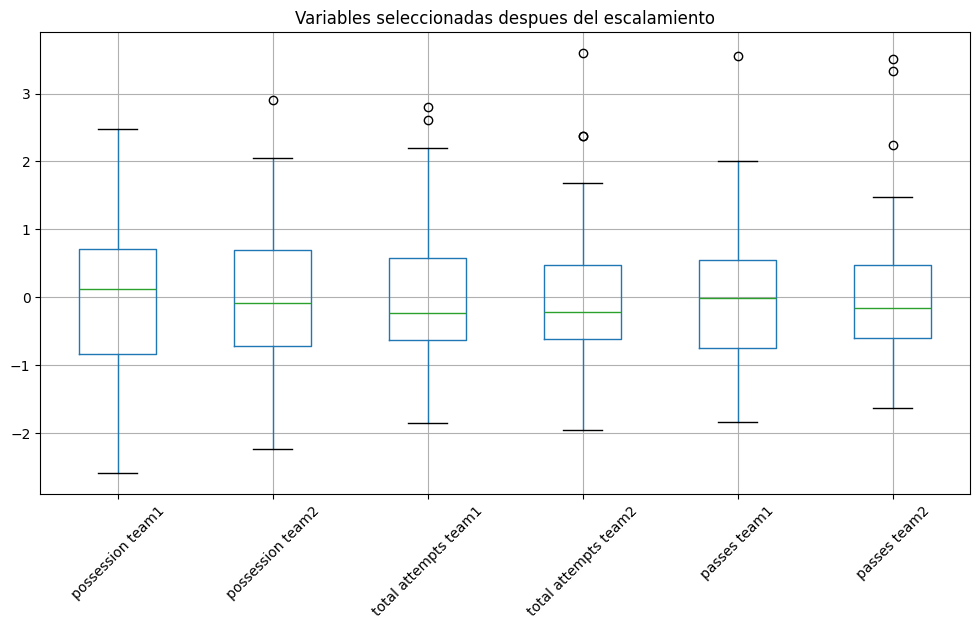

In [26]:
columnas_visualizacion = [
    'possession team1',
    'possession team2',
    'total attempts team1',
    'total attempts team2',
    'passes team1',
    'passes team2'
]

columnas_visualizacion = [c for c in columnas_visualizacion if c in df.columns]

df[columnas_visualizacion].boxplot(figsize=(12, 6))
plt.title("Variables seleccionadas despues del escalamiento")
plt.xticks(rotation=45)
plt.show()

# 13. Vista final del dataset preprocesado

Finalmente, se muestra la dimensión final del dataset y las primeras filas. Esta evidencia permite comprobar que el pipeline produjo una tabla limpia, numérica y lista para análisis posteriores.

In [27]:
print("Dataset final:", df.shape)
df.head()

Dataset final: (64, 167)


,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,total attempts team1,total attempts team2,conceded team1,conceded team2,goal inside the penalty area team1,...,category_Group F,category_Group G,category_Group H,category_Play-off for third place,category_Quarter-final,category_Round of 16,category_Semi-final,result_team1_draw,result_team1_loss,result_team1_win
0,-0.222014,0.543986,-1.643741,-1.025341,0.850178,-1.244675,-0.916545,0.850178,-1.025341,-0.947034,...,0,0,0,0,0,0,0,0,1,0
1,2.315290,-2.062941,-1.222943,2.872985,0.850178,0.376886,-0.569451,0.850178,2.872985,2.921701,...,0,0,0,0,0,0,0,0,0,1
2,-0.052861,0.123514,-0.381348,-1.025341,0.850178,0.579581,-0.395904,0.850178,-1.025341,-0.947034,...,0,0,0,0,0,0,0,0,1,0
3,0.539177,-0.381053,-0.802146,-0.375620,-0.104408,-1.041980,-0.742998,-0.104408,-0.375620,-0.302245,...,0,0,0,0,0,0,0,1,0,0
4,1.638676,-1.642469,0.039450,-0.375620,0.850178,0.579581,-1.437185,0.850178,-0.375620,-0.302245,...,0,0,0,0,0,0,0,0,1,0


También se puede guardar el dataset procesado para que las siguientes fases del proyecto lo reutilicen sin repetir manualmente todo el proceso.

La ruta propuesta corresponde a la estructura profesional del repositorio:

`../data/processed/fifa_world_cup_matches_processed.csv`

Si la carpeta no existe, se crea automáticamente.

In [28]:
from pathlib import Path

ruta_salida = Path("../data/processed/fifa_world_cup_matches_processed.csv")
ruta_salida.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(ruta_salida, index=False)
print(f"Dataset procesado guardado en: {ruta_salida}")

Dataset procesado guardado en: ../data/processed/fifa_world_cup_matches_processed.csv


# Evidencia de cumplimiento de la rúbrica de Fase 2

| Criterio de evaluación | Evidencia en el notebook |
|---|---|
| Codificación funcional y arquitectura básica del script | Funciones con parámetros claros, docstrings y flujo operacional documentado. |
| Preprocesamiento y transformación del dataset | Revisión de nulos, duplicados, casting de porcentajes, fecha/hora, variables derivadas, One-Hot Encoding y escalamiento. |
| Validación técnica y verificación del código | Uso de `assert`, pruebas de casos normales, casos límite y excepciones controladas. |
| Preprocesamiento y transformación de datos | Dataset final numérico, consistente y listo para análisis posteriores. |
| Notebook final ejecutado y documentado | Celdas ordenadas según obtención, limpieza, transformación, escalamiento y validación; con explicaciones por bloque. |
| Repositorio GitHub actualizado | El notebook debe ubicarse en la carpeta F2 o notebooks, junto con README actualizado, commits y dataset procesado. |

Esta tabla permite relacionar explícitamente el trabajo técnico con los criterios solicitados por la evaluación sumativa.


# 14. Conclusiones de la Fase 2

Durante esta fase se construyó un pipeline completo para el dataset **FIFA World Cup 2022**, siguiendo el flujo de obtención, exploración, limpieza, transformación, escalamiento y validación.

El proceso permitió verificar que el dataset original no presenta valores nulos ni duplicados críticos. Además, se normalizaron los nombres de columnas, se transformaron porcentajes a formato numérico, se derivaron variables temporales desde fecha y hora, se creó una variable de resultado deportivo y se codificaron variables categóricas mediante One-Hot Encoding.

Las variables numéricas continuas fueron escaladas con `StandardScaler`, lo que permite dejarlas en una escala comparable para análisis posteriores. La validación técnica confirmó que el dataset final no contiene valores nulos, no conserva columnas de texto y mantiene coherencia en los grupos One-Hot.

Cada transformación fue implementada mediante funciones documentadas, con parámetros claros y verificaciones intermedias. Esto fortalece la reproducibilidad, trazabilidad y mantenibilidad del proyecto, cumpliendo con los criterios técnicos de la Fase 2.